## Imports

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading

In [31]:
irrigations_train = pd.read_csv('data/train.csv')
irrigations_test = pd.read_csv('data/test.csv')

## Inpecting the Data

In [32]:
# no missing values
print("train missing values: \n", irrigations_train.isnull().sum())
print("test missing values: \n", irrigations_test.isnull().sum())

irrigations_train.info()
irrigations_test.describe()

train missing values: 
 id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64
test missing values: 
 id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type   

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,6.480929,37.307614,0.922279,1.745251,27.001666,61.511319,1464.525885,7.513277,10.386531,7.508192,62.356021
std,77942.430678,0.922187,16.375273,0.365757,0.951329,8.630706,19.690278,612.521709,2.002661,5.683215,4.218736,34.225278
min,630000.000000,4.800000,8.010000,0.300000,0.100000,12.010000,25.000000,1.640000,4.000000,0.500000,0.300000,0.020000
25%,697499.750000,5.680000,23.340000,0.610000,0.930000,19.500000,45.310000,956.100000,5.760000,5.320000,3.880000,33.190000
50%,764999.500000,6.440000,37.770000,0.900000,1.740000,26.960000,61.620000,1476.030000,7.590000,10.520000,7.360000,61.220000
75%,832499.250000,7.260000,51.200000,1.220000,2.580000,34.530000,79.090000,2055.750000,9.250000,15.430000,11.140000,92.720000
max,899999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


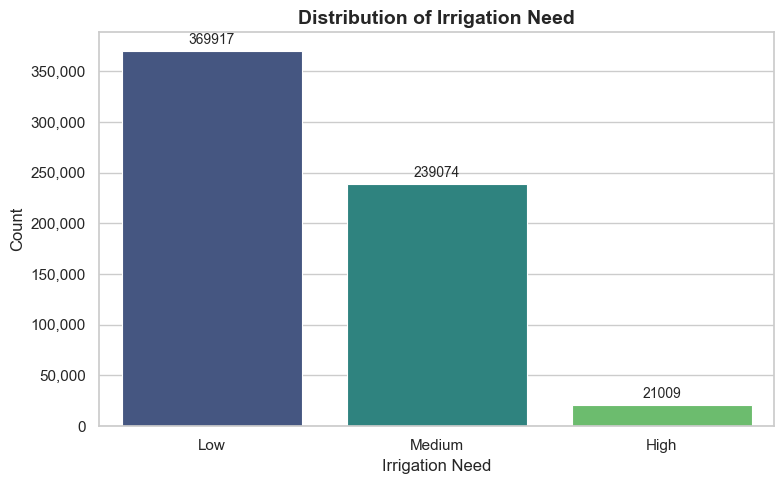

In [33]:
# Distribution of Irrigation Need (categorical — bar counts, not histogram + KDE)
sns.set_theme(style="whitegrid", context="notebook")
preferred = ["Low", "Medium", "High"]
order = [c for c in preferred if c in set(irrigations_train["Irrigation_Need"])]
if not order:
    order = irrigations_train["Irrigation_Need"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=irrigations_train,
    x="Irrigation_Need",
    order=order,
    hue="Irrigation_Need",
    hue_order=order,
    palette="viridis",
    legend=False,
    ax=ax,
    edgecolor="white",
    linewidth=0.8,
)
ax.set_title("Distribution of Irrigation Need", fontsize=14, fontweight="semibold")
ax.set_xlabel("Irrigation Need")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

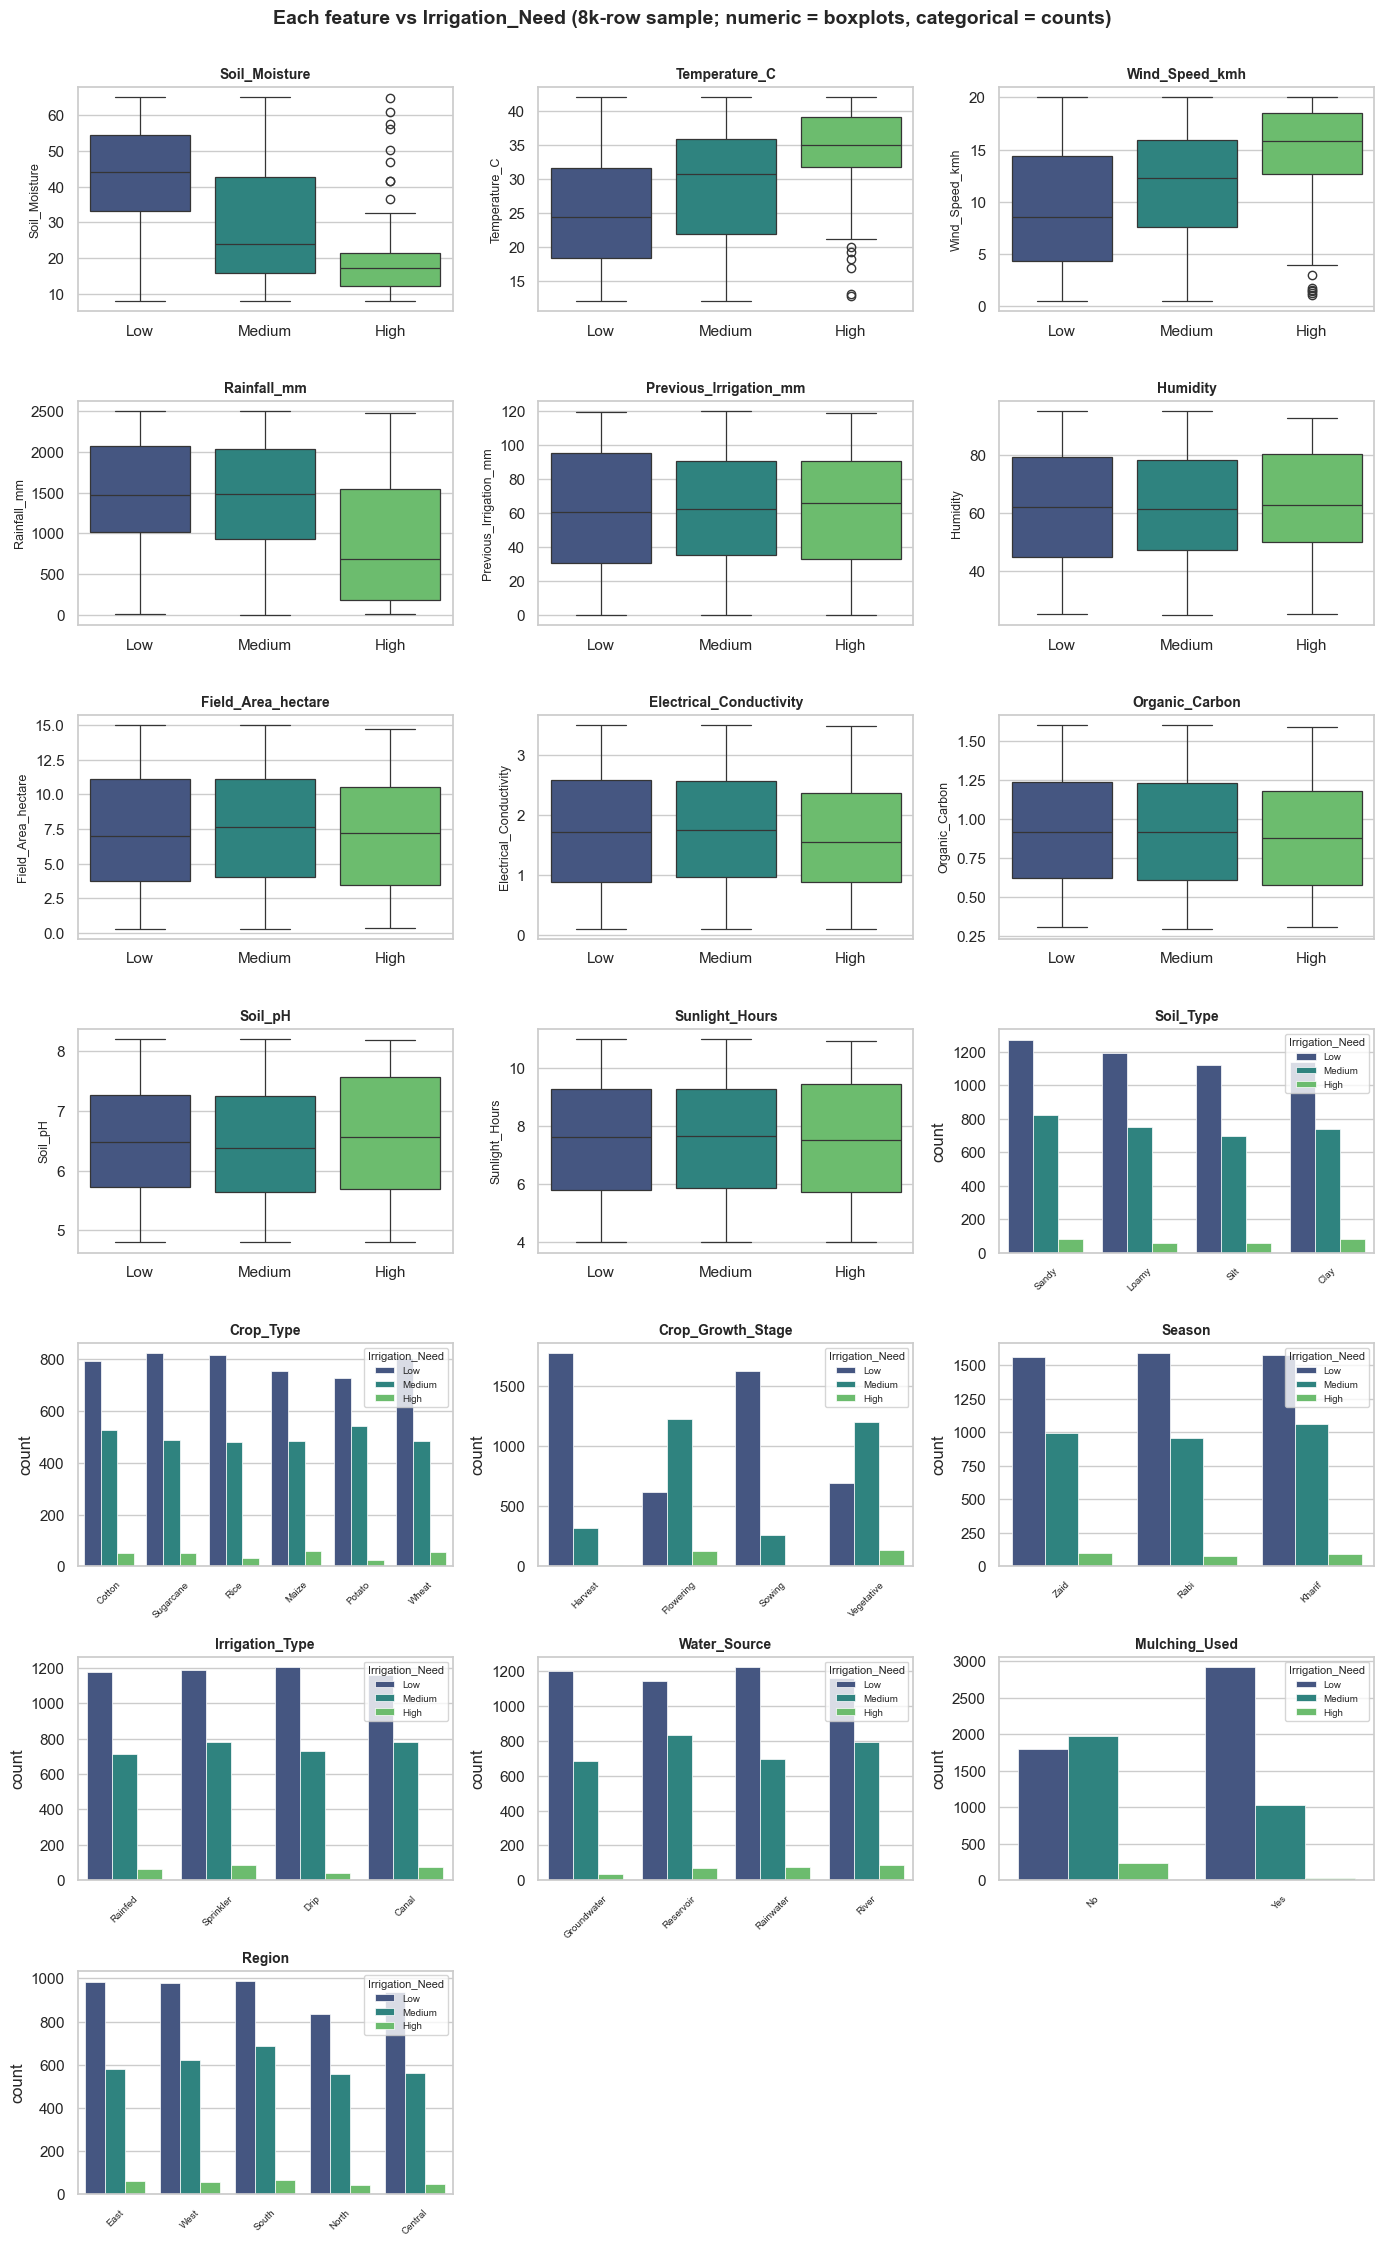

In [34]:
# One subplot per feature vs Irrigation_Need (run cell above first for numerical / categorical / feature_cols)
sns.set_theme(style="whitegrid", context="notebook")
_df = irrigations_train.copy()
preferred = ["Low", "Medium", "High"]
order = [c for c in preferred if c in set(_df["Irrigation_Need"])]
plot_sample = _df.sample(n=min(8000, len(_df)), random_state=42)

n = len(feature_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, feature_cols):
    if col in numerical:
        sns.boxplot(
            data=plot_sample,
            x="Irrigation_Need",
            y=col,
            order=order,
            hue="Irrigation_Need",
            hue_order=order,
            palette="viridis",
            legend=False,
            ax=ax,
            linewidth=0.9,
        )
        ax.set_ylabel(col, fontsize=9)
    else:
        sns.countplot(
            data=plot_sample,
            x=col,
            hue="Irrigation_Need",
            hue_order=order,
            palette="viridis",
            ax=ax,
            edgecolor="white",
            linewidth=0.5,
        )
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.legend(title="Irrigation_Need", fontsize=7, title_fontsize=8, loc="upper right")
    ax.set_title(col, fontsize=10, fontweight="semibold")
    ax.set_xlabel("")

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Each feature vs Irrigation_Need (8k-row sample; numeric = boxplots, categorical = counts)",
    fontsize=14,
    fontweight="semibold",
    y=1.002,
)
plt.tight_layout()
plt.show()

## Interaction features

Engineered interactions (see table in project notes):

- **Numerical × numerical**: products (e.g. temperature × humidity, rainfall × soil moisture).
- **Categorical × categorical**: concatenated labels (e.g. soil × crop, stage × season).
- **Categorical × numerical**: one-hot encoding of the category multiplied by the numeric column (columns aligned to **train** categories so train/test match).

In [35]:
irrigations_train['Previous_Irrigation_mm'].head()

0    112.16
1     47.16
2    110.38
3     53.85
4     93.19
Name: Previous_Irrigation_mm, dtype: float64

In [36]:
def add_interaction_features(train_df, test_df):
    """Add numerical×numerical, categorical×categorical, and categorical×numerical columns."""
    train = train_df.copy()
    test = test_df.copy()

    # Numerical × Numerical (products)
    nn_pairs = [
        # temperatur of the air directly correlates with humidity
        ("Temp_x_Humidity", "Temperature_C", "Humidity"),
        # rainfall directly correlates with soil moisture
        ("Rain_x_Soil_Moisture", "Rainfall_mm", "Soil_Moisture"),
        # if previous irrigation is high, soil moisture is high
        ("PrevIrr_x_Soil_Moisture", "Previous_Irrigation_mm", "Soil_Moisture"),
        # high sunlight intensity directly correlates with temperature
        ("Sunlight_x_Temp", "Sunlight_Hours", "Temperature_C"),
        # high electrical conductivity directly correlates with soil pH
        ("EC_x_pH", "Electrical_Conductivity", "Soil_pH"),
    ]

    # create new columns for each interaction pair 
    for new_col, a, b in nn_pairs:
        train[new_col] = train[a] * train[b]
        test[new_col] = test[a] * test[b]

    # Net water balance feature
    # Evapotranspiration: how much water is loss to the air and soil via evporation
    # Formula: Temp*sunlightHours*(1(-Humidityy)/100)
    if "Evapotranspiration_estimate" not in train.columns:
        train["Evapotranspiration_estimate"] = (
            train["Temperature_C"] * train["Sunlight_Hours"] * (1 - train["Humidity"] / 100.0)
        )
    if "Evapotranspiration_estimate" not in test.columns:
        test["Evapotranspiration_estimate"] = (
            test["Temperature_C"] * test["Sunlight_Hours"] * (1 - test["Humidity"] / 100.0)
        )

    # Formula: previousIrrigation water + Rainfall water - Evaporated water through the air and soil 
    train["net_water"] = (
        train["Previous_Irrigation_mm"] + train["Rainfall_mm"] - train["Evapotranspiration_estimate"]
    )
    test["net_water"] = (
        test["Previous_Irrigation_mm"] + test["Rainfall_mm"] - test["Evapotranspiration_estimate"]
    )

    meta = {
        "numerical_interactions": [p[0] for p in nn_pairs] +
        ["Evapotranspiration_estimate", "net_water"],
    }
    return train, test, meta


irrigations_train, irrigations_test, INTERACTION_META = add_interaction_features(
    irrigations_train, irrigations_test
)
print(irrigations_train.columns)

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'Temp_x_Humidity', 'Rain_x_Soil_Moisture', 'PrevIrr_x_Soil_Moisture',
       'Sunlight_x_Temp', 'EC_x_pH', 'Evapotranspiration_estimate',
       'net_water'],
      dtype='str')
